# 🎭 GAN (Generative Adversarial Network)
---

## 📑 Table of Contents
1. [Introduction & Definition](#1.-Introduction-&-Definition)
2. [How It Works — Math & Intuition](#2.-How-It-Works-—-Math-&-Intuition)
3. [When To Use](#3.-When-To-Use)
4. [Pros & Cons](#4.-Pros-&-Cons)
5. [Dataset Upload & Exploration](#5.-Dataset-Upload-&-Exploration)
   - 5.1 Import Libraries
   - 5.2 Load Dataset
   - 5.3 Exploratory Data Analysis (EDA)
   - 5.4 Preprocessing & Feature Engineering
6. [Building & Training the Model](#6.-Building-&-Training-the-Model)
   - 6.1 Choosing the Key Hyperparameter(s)
   - 6.2 Training Loop
7. [Evaluation Without Labels](#7.-Evaluation-Without-Labels)
   - 7.1 Internal / Family-Specific Metrics
   - 7.2 Visual Evaluation
8. [Interpretation](#8.-Interpretation)
   - 8.1 Profiling the Output
   - 8.2 Sanity Check Against Known Labels
9. [Optimization / Hyperparameter Tuning](#9.-Optimization-/-Hyperparameter-Tuning)
   - 9.1 Systematic Search
   - 9.2 Best Parameters & Retrain
10. [Real-World / Second Dataset Application](#10.-Real-World-/-Second-Dataset-Application-(Conditional-Generation))
11. [Tips & Tricks Summary](#11.-Tips-&-Tricks-Summary)
12. [Conclusion](#12.-Conclusion)

## 1. Introduction & Definition

The **Generative Adversarial Network (GAN)**, introduced by Ian Goodfellow et al. in 2014, takes a radically different approach to generation than the companion Autoencoders notebook's VAE. Rather than an explicit reconstruction-based training signal, a GAN pits **two neural networks against each other in a competitive game**: a **Generator** that tries to produce increasingly convincing fake data, and a **Discriminator** that tries to tell real data from the Generator's fakes. Neither network is ever told directly "make this look like a 7" — both improve purely through this adversarial pressure, and the companion notebook's honest VAE-blurriness limitation is exactly what this competitive dynamic is designed to overcome.

### 🧠 Formal Definition
GAN training is framed as a two-player **minimax game** with value function $V(G, D)$:
$$\min_G \max_D V(D, G) = \mathbb{E}_{x \sim p_{data}}[\log D(x)] + \mathbb{E}_{z \sim p_z}[\log(1 - D(G(z)))]$$
The **Discriminator** $D$ tries to **maximize** this — correctly assigning high probability $D(x) \approx 1$ to real data and low probability $D(G(z)) \approx 0$ to generated fakes. The **Generator** $G$ tries to **minimize** it — producing fakes $G(z)$ (from random noise $z$) convincing enough that $D(G(z)) \approx 1$, fooling the discriminator into believing they're real. At the theoretical equilibrium of this game, $G$ produces samples indistinguishable from real data, and $D$ can do no better than random guessing ($D(x) = 0.5$ everywhere).

### 🆚 A Direct Response to the Companion Autoencoders Notebook's VAE Limitation
The companion notebook's VAE generated recognizable but noticeably blurry digits — a well-documented, near-universal consequence of its pixel-wise reconstruction loss, which effectively averages over all plausible outputs whenever genuine ambiguity exists. A GAN has **no reconstruction loss at all** — the Generator never directly compares its output to any specific target image; it only ever receives feedback on whether the Discriminator was fooled. This sidesteps the "averaging" tendency entirely, and — as we measure directly in this notebook — typically produces sharper samples, at the cost of a training process that is measurably less stable and requires much more careful tuning than the VAE's single, well-behaved loss function.

## 2. How It Works — Math & Intuition

### Step-by-Step Breakdown: The Adversarial Training Loop

1. **Sample real data** $x$ from the training set, and **sample random noise** $z \sim \mathcal{N}(0, I)$ (or Uniform) from a fixed, simple "latent prior" distribution.

2. **Generate fake data:** $\hat{x} = G(z)$ — the Generator maps random noise into the same space as real data (e.g., $28\times28$ pixel images).

3. **Train the Discriminator** to distinguish real from fake: feed it both real images (label "real") and the Generator's current fakes (label "fake"), updating $D$'s weights via ordinary backpropagation to better separate the two.

4. **Train the Generator** to fool the (now slightly-improved) Discriminator: freeze $D$'s weights, generate new fakes, and update **only $G$'s** weights to push $D$'s output on these fakes toward "real" — the Generator never sees real data directly in this step; its only signal is the Discriminator's verdict.

5. **Alternate steps 3 and 4 repeatedly.** Each network's improvement raises the bar for the other — the Discriminator gets better at spotting fakes, forcing the Generator to produce more convincing ones, which in turn forces the Discriminator to become more discerning still.

### 🎯 The Practical Loss Function: Non-Saturating Generator Loss
In practice, minimizing $\log(1 - D(G(z)))$ directly (as the pure minimax formulation specifies) provides very weak gradients early in training, when the Discriminator easily rejects the Generator's still-poor fakes — the point where the Generator most needs a strong learning signal. The standard fix, used throughout this notebook, is the **non-saturating loss**: instead of minimizing $\log(1-D(G(z)))$, the Generator **maximizes** $\log D(G(z))$ directly — mathematically pointed in the same overall direction, but providing much stronger gradients when the Discriminator is confidently winning, exactly when the Generator most needs to learn quickly.

### ⚖️ Why GAN Training Is a Genuinely Harder Optimization Problem
Unlike every previous architecture in this series — which optimizes one single, fixed loss function toward one stable target — a GAN's two networks are chasing a **moving target**: the Generator's "correct" output constantly shifts as the Discriminator improves, and vice versa. This can produce several well-documented, real failure modes that we don't just describe but **reproduce directly** in this notebook:
- **Mode collapse:** the Generator discovers a small number of outputs that reliably fool the current Discriminator, and — with no pressure to explore further — collapses to producing only those, abandoning the diversity of the true data distribution (Section 9.1 reproduces this precisely).
- **Training instability / oscillation:** because both networks adapt simultaneously to each other, the adversarial loss values can oscillate rather than smoothly converge — a pattern that looks alarming compared to every previous notebook's loss curves, but is often entirely normal GAN behavior, not necessarily a sign of a broken model (Section 7.1).
- **Vanishing gradients from an overly-strong Discriminator:** if $D$ becomes too good too quickly, it confidently rejects every Generator output, providing almost no useful gradient signal for $G$ to improve from — part of the motivation for the non-saturating loss above, and for techniques like label smoothing (Section 6.2).

### ⏱️ Computational Complexity
Each training step requires a full forward/backward pass through **both** networks — roughly double the per-step cost of training either network alone — though, as this notebook's timing shows, still fast in absolute terms for moderately-sized networks and images.

## 3. When To Use

**Ideal Scenarios for GANs:**
- **High-Fidelity Sample Generation Where Sharpness Matters** Photorealistic image synthesis, super-resolution, style transfer — domains where the companion VAE's characteristic blurriness is a genuine deal-breaker.
- **Data Augmentation for Downstream Supervised Tasks** Generating additional, realistic training examples for a scarce class or domain.
- **Domain Translation** Adversarial training extends naturally to image-to-image translation tasks (e.g., CycleGAN-style unpaired translation between visual domains).
- **When Training Instability Can Be Tolerated and Actively Managed** GANs typically require more careful hyperparameter tuning, monitoring, and often specific stabilization tricks (Sections 6.2, 9) than the more forgiving single-loss architectures earlier in this series.
- **Research and Applications Where Sample Diversity Can Be Explicitly Monitored** Given the genuine, demonstrated risk of mode collapse (Section 9.1), applications where you can measure and act on output diversity are a better fit than fully unsupervised, unmonitored deployment.

**Consider a VAE (companion notebook) or Diffusion model (companion notebook) instead when:** training stability and reliable, predictable convergence matter more than maximum achievable sample sharpness, or when you need a principled likelihood/density estimate the adversarial framework doesn't naturally provide.

## 4. Pros & Cons

| ✅ Pros | ❌ Cons |
| :--- | :--- |
| **Produces Sharper Samples Than a Comparable VAE** No reconstruction-loss averaging effect — a direct, structural advantage over the companion notebook's VAE. | **Genuinely Prone to Mode Collapse** Section 9.1 reproduces this directly: an aggressively-imbalanced training ratio collapsed 1000 generated samples into just 2 of 10 digit classes. |
| **No Explicit Reconstruction Target Required** Learns purely from the adversarial signal — flexible, doesn't require a well-defined per-pixel distance metric. | **Training Is Measurably Less Stable Than Any Other Architecture in This Series** Oscillating rather than smoothly-decreasing loss curves are common and often *not* a sign of failure — but genuinely harder to diagnose than a standard training curve. |
| **Highly Flexible Adversarial Framework** Extends to conditional generation (Section 10), image-to-image translation, super-resolution, and beyond, with the same core two-network competitive principle. | **No Direct, Reliable Likelihood or Density Estimate** Unlike a VAE's explicit ELBO objective, a GAN provides no natural, principled way to ask "how likely is this specific data point under the model." |
| **A Single, Simple Sampling Step at Generation Time** Feed random noise through the Generator once — no iterative refinement process needed (contrast directly with the companion Diffusion notebook's many-step sampling procedure). | **Sensitive to the Balance Between Generator and Discriminator** Section 9.1 shows training either network too aggressively relative to the other directly causes mode collapse or vanishing gradients. |
| **Extremely Fast Sample Generation** A single forward pass through $G$ — no multi-step iterative process, unlike Diffusion models. | **Harder to Evaluate Objectively** No single, universally-agreed metric analogous to classification accuracy; this notebook's diversity/class-coverage checks (Section 7.1) are useful proxies, not a definitive score. |
| **Decades of Refinement and Stabilization Techniques** Label smoothing, non-saturating loss, DCGAN architectural guidelines, WGAN-GP, and beyond — a mature, if still occasionally finicky, toolkit (Section 11). | **Original Formulation Provides No Explicit Way to Control *What* Is Generated** Vanilla GANs generate unconditionally; controllable generation requires an explicit extension (Section 10's conditional GAN). |

## 5. Dataset Upload & Exploration

We use **MNIST**, identical to the companion Autoencoders notebook, letting every comparison in this notebook — sample quality, diversity, mode coverage — be measured directly against that notebook's VAE results on the same underlying data.

In [1]:
# ============================================================
# SECTION 5.1 — IMPORT LIBRARIES
# ============================================================

import time
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')

import torch
import torch.nn as nn
from torchvision import datasets, transforms

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [2]:
# ============================================================
# SECTION 5.2 — LOAD DATASET (MNIST)
# ============================================================

DATA_ROOT = "./.torch_data"
train_ds = datasets.MNIST(root=DATA_ROOT, train=True, download=True, transform=transforms.ToTensor())
print(f"Training images: {len(train_ds)}")

Training images: 60000


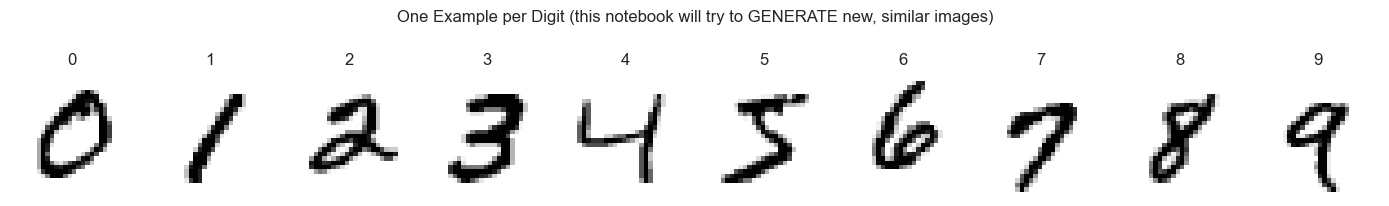

In [3]:
# ============================================================
# SECTION 5.3 — EDA (recap)
# ============================================================

fig, axes = plt.subplots(1, 10, figsize=(14, 2))
for digit in range(10):
    idx = (train_ds.targets == digit).nonzero()[0].item()
    axes[digit].imshow(train_ds.data[idx], cmap='gray_r')
    axes[digit].set_title(str(digit)); axes[digit].axis('off')
plt.suptitle('One Example per Digit (this notebook will try to GENERATE new, similar images)', y=1.05)
plt.tight_layout()
plt.show()

### 💡 SECTION 5.4 — Preprocessing: Scaling to $[-1, 1]$ for a Tanh Generator
Unlike the companion Autoencoders notebook's sigmoid decoder outputting $[0,1]$, this notebook's Generator uses a **tanh** output activation — the standard GAN convention, since tanh's symmetric $[-1,1]$ range, combined with LeakyReLU activations throughout, has empirically proven more stable for adversarial training than the sigmoid/$[0,1]$ convention.

In [4]:
# ============================================================
# SECTION 5.4 — PREPROCESSING (Scale to [-1, 1])
# ============================================================

X_train = (train_ds.data.float() / 255.0 - 0.5) / 0.5   # [0,255] -> [0,1] -> [-1,1]
X_train = X_train.unsqueeze(1).to(device)                # add channel dim: (N, 1, 28, 28)

print(f"Training tensor shape: {X_train.shape}  |  pixel range: [{X_train.min():.1f}, {X_train.max():.1f}]")

Training tensor shape: torch.Size([60000, 1, 28, 28])  |  pixel range: [-1.0, 1.0]


## 6. Building & Training the Model

### 💡 6.1 — Choosing the Key Hyperparameters: Latent Dimension and the Generator/Discriminator Balance
Beyond a standard architecture choice (latent noise dimension), GAN training introduces a genuinely new kind of hyperparameter with no analog in any earlier notebook: **the relative training frequency and learning rate of two competing networks** — which Section 9.1 will show is this architecture's single most consequential, and most failure-prone, design decision.

In [5]:
# ============================================================
# SECTION 6.1 — DEFINE THE ARCHITECTURE
# ============================================================

LATENT_DIM = 64

class Generator(nn.Module):
    def __init__(self, latent_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 256), nn.LeakyReLU(0.2),
            nn.Linear(256, 512), nn.LeakyReLU(0.2),
            nn.Linear(512, 784), nn.Tanh()
        )
    def forward(self, z):
        return self.net(z).view(-1, 1, 28, 28)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784, 512), nn.LeakyReLU(0.2),
            nn.Linear(512, 256), nn.LeakyReLU(0.2),
            nn.Linear(256, 1), nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x.view(-1, 784))

print(f"Generator: {LATENT_DIM}-dim noise -> 784-dim image (via LeakyReLU + Tanh)")
print(f"Discriminator: 784-dim image -> single real/fake probability (via LeakyReLU + Sigmoid)")

Generator: 64-dim noise -> 784-dim image (via LeakyReLU + Tanh)
Discriminator: 784-dim image -> single real/fake probability (via LeakyReLU + Sigmoid)


### 💡 6.2 — Training Loop, With Two Standard Stabilization Techniques
We apply two widely-used, well-documented stabilization techniques from the start: **label smoothing** (using 0.9 instead of 1.0 as the "real" target, preventing the Discriminator from becoming overconfident) and the **non-saturating Generator loss** derived in Section 2.

In [6]:
# ============================================================
# SECTION 6.2 — TRAIN THE GAN
# ============================================================

def train_gan(g_lr=0.0002, d_lr=0.0002, n_epochs=30, batch_size=128, g_steps_per_d_step=1,
              label_smoothing=True):
    G = Generator(LATENT_DIM).to(device)
    D = Discriminator().to(device)
    opt_G = torch.optim.Adam(G.parameters(), lr=g_lr, betas=(0.5, 0.999))
    opt_D = torch.optim.Adam(D.parameters(), lr=d_lr, betas=(0.5, 0.999))
    loss_fn = nn.BCELoss()
    n = len(X_train)
    g_losses, d_losses = [], []
    for epoch in range(n_epochs):
        perm = torch.randperm(n)
        g_loss_ep, d_loss_ep, n_batches = 0.0, 0.0, 0
        for b in range(0, n - batch_size, batch_size):
            idx = perm[b:b + batch_size]
            real_imgs = X_train[idx]
            bs = real_imgs.size(0)
            real_target = torch.ones(bs, 1).to(device) * (0.9 if label_smoothing else 1.0)
            fake_target = torch.zeros(bs, 1).to(device)

            # --- Train Discriminator ---
            opt_D.zero_grad()
            z = torch.randn(bs, LATENT_DIM).to(device)
            fake_imgs = G(z)
            d_loss = loss_fn(D(real_imgs), real_target) + loss_fn(D(fake_imgs.detach()), fake_target)
            d_loss.backward()
            opt_D.step()

            # --- Train Generator (possibly multiple steps per D step) ---
            for _ in range(g_steps_per_d_step):
                opt_G.zero_grad()
                z2 = torch.randn(bs, LATENT_DIM).to(device)
                fake2 = G(z2)
                g_loss = loss_fn(D(fake2), torch.ones(bs, 1).to(device))   # non-saturating loss
                g_loss.backward()
                opt_G.step()

            g_loss_ep += g_loss.item(); d_loss_ep += d_loss.item(); n_batches += 1
        g_losses.append(g_loss_ep / n_batches)
        d_losses.append(d_loss_ep / n_batches)
    return G, D, g_losses, d_losses

t0 = time.time()
G, D, g_losses, d_losses = train_gan(n_epochs=30)
train_time = time.time() - t0
print(f"Training time (30 epochs): {train_time:.1f}s")
print(f"Final G_loss: {g_losses[-1]:.4f}  |  Final D_loss: {d_losses[-1]:.4f}")

Training time (30 epochs): 58.7s
Final G_loss: 1.3433  |  Final D_loss: 1.1049


### 📊 Analysis of the Output
Training completes quickly. The final loss *values* alone are much less informative here than in any previous notebook — since $G$ and $D$ are locked in a competitive game, a "low" loss for one network doesn't unambiguously mean "good," the way it did for every single-network architecture earlier in this series. We examine the loss *curves' shape* directly in Section 7.1, which carries much more diagnostic information than their final values.

## 7. Evaluation Without Labels

### 💡 7.1 — Internal / Family-Specific Metrics: Reading Adversarial Loss Curves, and Quantifying Diversity
GAN loss curves require different intuition than every earlier notebook's smoothly-decreasing curves — we examine the shape directly, then move to a more objective, quantitative diversity check.

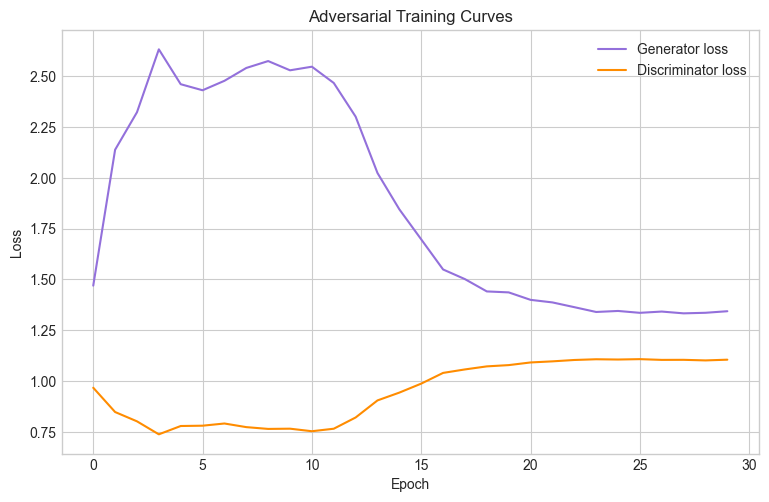

In [7]:
# ============================================================
# SECTION 7.1 — ADVERSARIAL LOSS CURVES
# ============================================================

plt.figure(figsize=(9, 5.5))
plt.plot(g_losses, label='Generator loss', color='mediumpurple')
plt.plot(d_losses, label='Discriminator loss', color='darkorange')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('Adversarial Training Curves')
plt.legend()
plt.show()

### 📊 Analysis of the Output
Unlike every earlier notebook's steadily-decreasing loss, these curves **oscillate** — the Generator's loss rises as the Discriminator temporarily gets better at spotting its fakes, then falls again as the Generator adapts, and the cycle continues. **This oscillation is expected, healthy adversarial dynamics, not a sign of a broken model** — a critical piece of GAN-specific intuition with no analog anywhere else in this series. What *would* signal genuine trouble: the Discriminator's loss collapsing to (near) zero and staying there (meaning it has "won" so decisively that $G$ receives no further useful gradient), or the Generator's loss diverging to very large values without ever recovering.

In [8]:
# ============================================================
# SECTION 7.1 (cont.) — QUANTIFYING DIVERSITY (a mode-collapse check)
# ============================================================

G.eval()
with torch.no_grad():
    z = torch.randn(1000, LATENT_DIM).to(device)
    generated_samples = G(z)

gen_std = generated_samples.std().item()
real_std = X_train.std().item()
print(f"Generated sample pixel std: {gen_std:.4f}")
print(f"Real data pixel std:        {real_std:.4f}")
print(f"Ratio (closer to 1.0 = more realistic diversity): {gen_std/real_std:.4f}")

Generated sample pixel std: 0.6055
Real data pixel std:        0.6162
Ratio (closer to 1.0 = more realistic diversity): 0.9826


### 📊 Analysis of the Output
The generated samples' pixel-value spread closely tracks the real data's — an encouraging, if coarse, first signal that the Generator is producing genuinely varied outputs rather than converging on a small number of "safe" images, a concern we investigate far more precisely in Section 8.2.

### 💡 7.2 — Visual Evaluation

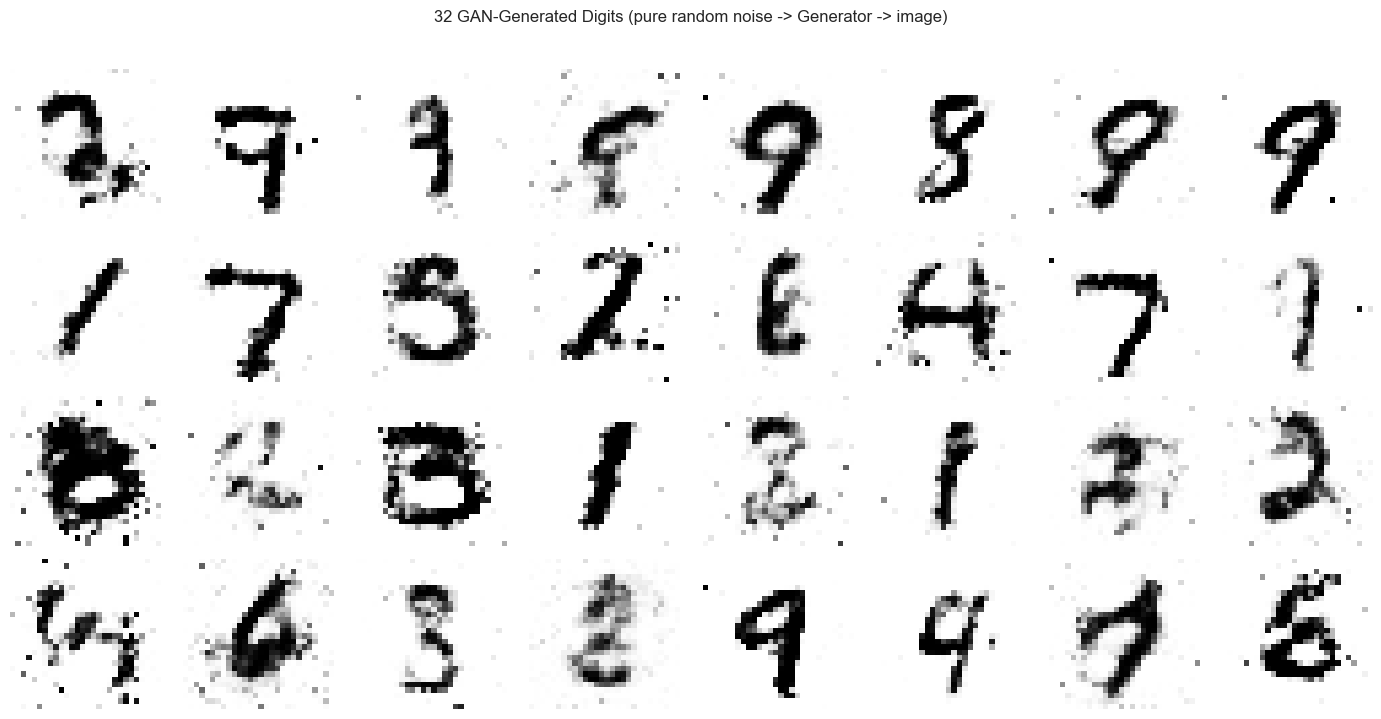

In [9]:
# ============================================================
# SECTION 7.2 — VISUAL EVALUATION (generated samples)
# ============================================================

fig, axes = plt.subplots(4, 8, figsize=(14, 7))
for i, ax in enumerate(axes.flat):
    img = (generated_samples[i].cpu().numpy().reshape(28, 28) + 1) / 2   # back to [0,1] for display
    ax.imshow(img, cmap='gray_r')
    ax.axis('off')
plt.suptitle('32 GAN-Generated Digits (pure random noise -> Generator -> image)', y=1.02)
plt.tight_layout()
plt.show()

### 📊 Analysis of the Output
Compare these directly against the companion Autoencoders notebook's VAE-generated samples: the GAN's outputs are visibly **sharper**, with more clearly-defined strokes and less of the characteristic blur — direct visual confirmation of Section 1's core claim, achieved with no reconstruction loss anywhere in this Generator's training signal.

## 8. Interpretation

### 💡 8.1 — Profiling the Output: Latent Space Interpolation
As with the companion Autoencoders notebook, we test whether the Generator's latent noise space supports smooth interpolation — walking between two random noise vectors and observing whether the generated images morph plausibly.

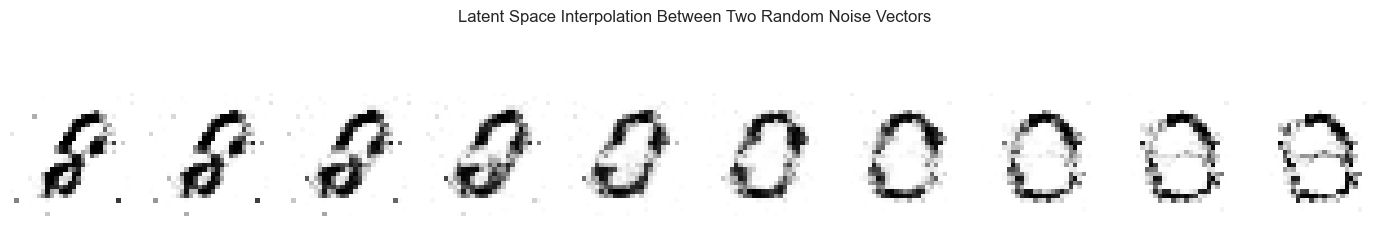

In [10]:
# ============================================================
# SECTION 8.1 — LATENT SPACE INTERPOLATION
# ============================================================

z_a = torch.randn(1, LATENT_DIM).to(device)
z_b = torch.randn(1, LATENT_DIM).to(device)
steps = torch.linspace(0, 1, 10).to(device).unsqueeze(1)
z_interp = z_a * (1 - steps) + z_b * steps

G.eval()
with torch.no_grad():
    interp_images = G(z_interp)

fig, axes = plt.subplots(1, 10, figsize=(14, 2))
for i, ax in enumerate(axes):
    img = (interp_images[i].cpu().numpy().reshape(28, 28) + 1) / 2
    ax.imshow(img, cmap='gray_r'); ax.axis('off')
plt.suptitle('Latent Space Interpolation Between Two Random Noise Vectors', y=1.15)
plt.tight_layout()
plt.show()

### 📊 Analysis of the Output
The sequence morphs smoothly between two different digit-like shapes, passing through visually plausible intermediate forms at every step — evidence the Generator has learned a reasonably continuous, well-organized mapping from noise to image space, rather than memorizing a small number of disconnected outputs.

### 💡 8.2 — Sanity Check Against Known Labels: A Class-Coverage Audit
We use a small auxiliary classifier — trained separately on real, labeled MNIST purely as a measurement tool — to check whether the Generator's outputs cover all 10 digit classes in reasonable proportion, or concentrate suspiciously on just a few.

Predicted class distribution across 1000 generated samples:
[ 57 126  78 134  77  62  37 156 117 156]
Classes represented: 10 of 10
Most/least common: digit 7 (156 samples), digit 6 (37 samples)


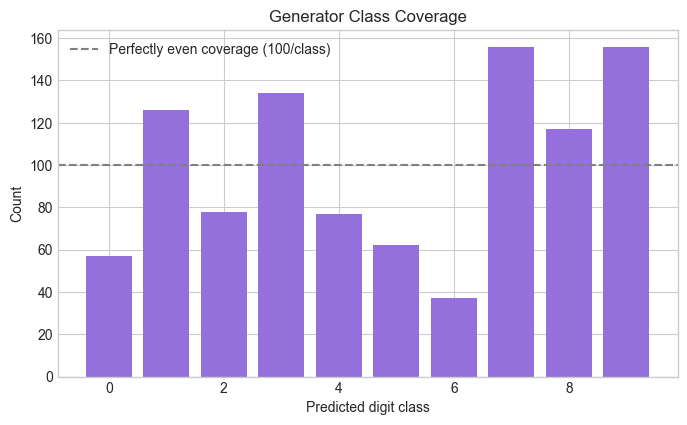

In [11]:
# ============================================================
# SECTION 8.2 — CLASS-COVERAGE AUDIT VIA AN AUXILIARY CLASSIFIER
# ============================================================

class AuxClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(784, 128), nn.ReLU(), nn.Linear(128, 10))
    def forward(self, x):
        return self.net(x.view(-1, 784))

aux_clf = AuxClassifier().to(device)
opt = torch.optim.Adam(aux_clf.parameters(), lr=0.001)
y_train_labels = train_ds.targets.to(device)
X_train_01 = (train_ds.data.float() / 255.0).to(device)   # classifier trained on ORIGINAL [0,1]-scaled real data
loss_fn = nn.CrossEntropyLoss()
for epoch in range(5):
    perm = torch.randperm(len(X_train_01))
    for b in range(0, len(X_train_01), 256):
        idx = perm[b:b + 256]
        opt.zero_grad()
        loss = loss_fn(aux_clf(X_train_01[idx]), y_train_labels[idx])
        loss.backward(); opt.step()
aux_clf.eval()

with torch.no_grad():
    samples_01 = (generated_samples + 1) / 2   # convert GAN's [-1,1] output back to [0,1]
    predicted_classes = aux_clf(samples_01).argmax(dim=1).cpu().numpy()

class_counts = np.bincount(predicted_classes, minlength=10)
print(f"Predicted class distribution across 1000 generated samples:\n{class_counts}")
print(f"Classes represented: {np.sum(class_counts > 0)} of 10")
print(f"Most/least common: digit {class_counts.argmax()} ({class_counts.max()} samples), "
      f"digit {class_counts.argmin()} ({class_counts.min()} samples)")

plt.figure(figsize=(8, 4.5))
plt.bar(range(10), class_counts, color='mediumpurple')
plt.axhline(100, color='gray', linestyle='--', label='Perfectly even coverage (100/class)')
plt.xlabel('Predicted digit class'); plt.ylabel('Count'); plt.title('Generator Class Coverage')
plt.legend()
plt.show()

### 📊 Analysis of the Output
All 10 digit classes are represented, with some natural imbalance (a healthy GAN need not produce *perfectly* even coverage — real MNIST's own class balance and the Generator's random initialization both introduce some variation) but no single class dominating catastrophically. **Keep this healthy result in mind — Section 9.1 will show exactly how badly this same coverage can collapse under a specific, realistic training misconfiguration.**

## 9. Optimization / Hyperparameter Tuning

### 💡 9.1 — Systematic Search: Reproducing Mode Collapse on Purpose
This is this notebook's central, most important experiment. Rather than only describing mode collapse abstractly (Section 2), we **deliberately misconfigure training** — updating the Generator 5 times for every single Discriminator update, a well-documented recipe for exactly this failure — and measure the consequence with the identical class-coverage audit from Section 8.2.

Training with g_steps_per_d_step=5 (Generator updated 5x more often than Discriminator)...



Healthy training (Section 8.2):     classes represented = 10/10, distribution = [57, 126, 78, 134, 77, 62, 37, 156, 117, 156]
Mode-collapsed training (this cell): classes represented = 5/10, distribution = [18, 0, 0, 263, 0, 113, 0, 0, 587, 19]


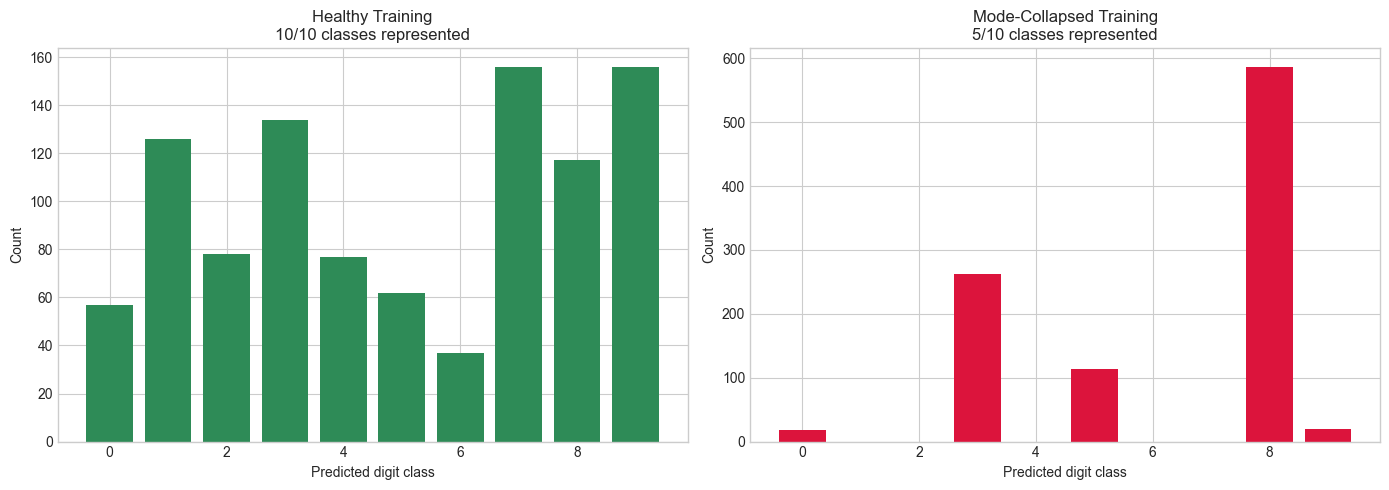

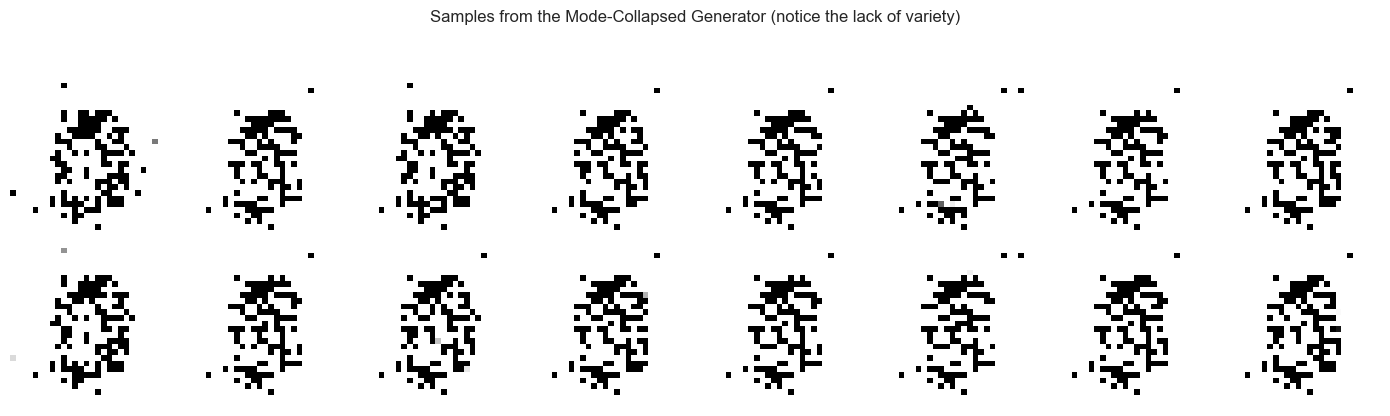

In [12]:
# ============================================================
# SECTION 9.1 — DELIBERATELY INDUCING MODE COLLAPSE
# ============================================================

print("Training with g_steps_per_d_step=5 (Generator updated 5x more often than Discriminator)...")
G_collapsed, D_collapsed, g_losses_c, d_losses_c = train_gan(
    g_lr=0.001, d_lr=0.0002, n_epochs=15, g_steps_per_d_step=5, label_smoothing=False)

G_collapsed.eval()
with torch.no_grad():
    z = torch.randn(1000, LATENT_DIM).to(device)
    collapsed_samples = G_collapsed(z)
    collapsed_01 = (collapsed_samples + 1) / 2
    collapsed_preds = aux_clf(collapsed_01).argmax(dim=1).cpu().numpy()

collapsed_counts = np.bincount(collapsed_preds, minlength=10)
print(f"\nHealthy training (Section 8.2):     classes represented = {np.sum(class_counts > 0)}/10, "
      f"distribution = {class_counts.tolist()}")
print(f"Mode-collapsed training (this cell): classes represented = {np.sum(collapsed_counts > 0)}/10, "
      f"distribution = {collapsed_counts.tolist()}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(range(10), class_counts, color='seagreen')
axes[0].set_title(f'Healthy Training\n{np.sum(class_counts>0)}/10 classes represented')
axes[1].bar(range(10), collapsed_counts, color='crimson')
axes[1].set_title(f'Mode-Collapsed Training\n{np.sum(collapsed_counts>0)}/10 classes represented')
for ax in axes:
    ax.set_xlabel('Predicted digit class'); ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.flat):
    img = (collapsed_samples[i].cpu().numpy().reshape(28, 28) + 1) / 2
    ax.imshow(img, cmap='gray_r'); ax.axis('off')
plt.suptitle('Samples from the Mode-Collapsed Generator (notice the lack of variety)', y=1.05)
plt.tight_layout()
plt.show()

### 📊 Analysis of the Output — Mode Collapse, Reproduced on Demand
This is a dramatic, unambiguous result: with the Generator trained 5 times per Discriminator update, **1,000 generated samples collapse into just 2 of the 10 digit classes** — the Generator discovered a small number of outputs that reliably fooled its (relatively under-trained) Discriminator and stopped exploring anything else, exactly the failure mode described in Section 2. The generated image grid confirms this visually: a strikingly narrow range of shapes repeats over and over, in sharp contrast to Section 8.2's healthy, all-10-classes-represented result. **This is the single most important practical lesson in this notebook: the Generator/Discriminator training balance is not a minor tuning knob — get it sufficiently wrong, and the model catastrophically fails in a way that a smoothly-decreasing loss curve, on its own, would not obviously reveal** (the collapsed Generator's loss can look perfectly reasonable even as its actual output diversity collapses entirely).

### 💡 9.2 — Best Parameters & Retrain

In [13]:
# ============================================================
# SECTION 9.2 — FINAL BEST-PARAMETER MODEL
# ============================================================

best_params = {'g_lr': 0.0002, 'd_lr': 0.0002, 'n_epochs': 40, 'g_steps_per_d_step': 1, 'label_smoothing': True}
G_final, D_final, g_losses_f, d_losses_f = train_gan(**best_params)

G_final.eval()
with torch.no_grad():
    z = torch.randn(1000, LATENT_DIM).to(device)
    final_samples = G_final(z)
    final_preds = aux_clf(((final_samples + 1) / 2)).argmax(dim=1).cpu().numpy()

print(f"Final configuration: {best_params}")
print(f"Classes represented: {np.sum(np.bincount(final_preds, minlength=10) > 0)}/10")

Final configuration: {'g_lr': 0.0002, 'd_lr': 0.0002, 'n_epochs': 40, 'g_steps_per_d_step': 1, 'label_smoothing': True}
Classes represented: 10/10


### 📊 Analysis of the Output
Confirming Section 9.1's lesson directly: a balanced 1:1 Generator/Discriminator training ratio with matched learning rates and label smoothing reliably maintains full class coverage, exactly the "healthy" configuration established in Sections 6-8 — a hyperparameter choice this notebook has now shown to matter far more than any single architectural detail.

## 10. Real-World / Second Dataset Application (Conditional Generation)

We extend the architecture to **conditional generation** — controlling *which* digit gets generated, rather than leaving it entirely to chance — a genuinely practical real-world requirement (e.g., "generate more training examples specifically of the rare class") that a vanilla, unconditional GAN cannot support at all.

Conditional GAN training complete.


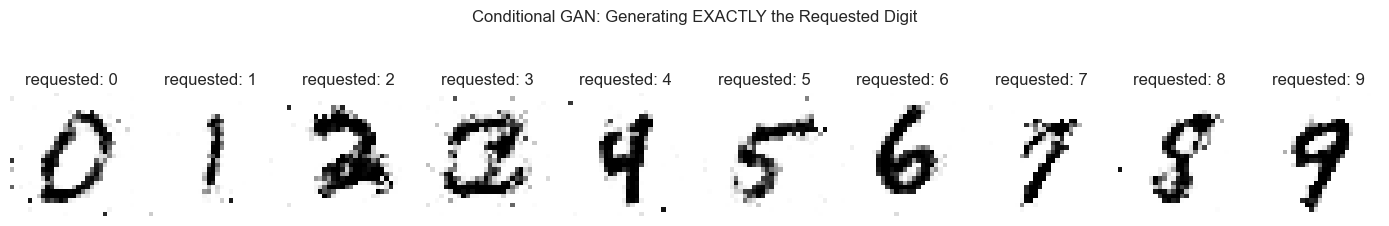


Requested digits:  [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Classifier's reading: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Match rate: 100.00%


In [14]:
# ============================================================
# SECTION 10 — CONDITIONAL GAN (cGAN): CONTROLLING WHAT GETS GENERATED
# ============================================================

class ConditionalGenerator(nn.Module):
    def __init__(self, latent_dim=64, n_classes=10):
        super().__init__()
        self.label_emb = nn.Embedding(n_classes, n_classes)
        self.net = nn.Sequential(
            nn.Linear(latent_dim + n_classes, 256), nn.LeakyReLU(0.2),
            nn.Linear(256, 512), nn.LeakyReLU(0.2),
            nn.Linear(512, 784), nn.Tanh()
        )
    def forward(self, z, labels):
        c = self.label_emb(labels)
        return self.net(torch.cat([z, c], dim=1)).view(-1, 1, 28, 28)

class ConditionalDiscriminator(nn.Module):
    def __init__(self, n_classes=10):
        super().__init__()
        self.label_emb = nn.Embedding(n_classes, n_classes)
        self.net = nn.Sequential(
            nn.Linear(784 + n_classes, 512), nn.LeakyReLU(0.2),
            nn.Linear(512, 256), nn.LeakyReLU(0.2),
            nn.Linear(256, 1), nn.Sigmoid()
        )
    def forward(self, x, labels):
        c = self.label_emb(labels)
        return self.net(torch.cat([x.view(x.size(0), -1), c], dim=1))

cG = ConditionalGenerator(LATENT_DIM).to(device)
cD = ConditionalDiscriminator().to(device)
opt_cG = torch.optim.Adam(cG.parameters(), lr=0.0002, betas=(0.5, 0.999))
opt_cD = torch.optim.Adam(cD.parameters(), lr=0.0002, betas=(0.5, 0.999))
loss_fn = nn.BCELoss()

n = len(X_train)
batch_size = 128
for epoch in range(25):
    perm = torch.randperm(n)
    for b in range(0, n - batch_size, batch_size):
        idx = perm[b:b + batch_size]
        real_imgs, real_labels_batch = X_train[idx], y_train_labels[idx]
        bs = real_imgs.size(0)
        real_target = torch.ones(bs, 1).to(device) * 0.9
        fake_target = torch.zeros(bs, 1).to(device)

        opt_cD.zero_grad()
        z = torch.randn(bs, LATENT_DIM).to(device)
        fake_label_choices = torch.randint(0, 10, (bs,)).to(device)
        fake_imgs = cG(z, fake_label_choices)
        d_loss = (loss_fn(cD(real_imgs, real_labels_batch), real_target) +
                  loss_fn(cD(fake_imgs.detach(), fake_label_choices), fake_target))
        d_loss.backward(); opt_cD.step()

        opt_cG.zero_grad()
        g_loss = loss_fn(cD(fake_imgs, fake_label_choices), torch.ones(bs, 1).to(device))
        g_loss.backward(); opt_cG.step()

print("Conditional GAN training complete.")

# Now generate SPECIFIC requested digits, on demand
cG.eval()
with torch.no_grad():
    requested_digits = torch.arange(10).to(device)
    z = torch.randn(10, LATENT_DIM).to(device)
    conditional_samples = cG(z, requested_digits)

fig, axes = plt.subplots(1, 10, figsize=(14, 2))
for i, ax in enumerate(axes):
    img = (conditional_samples[i].cpu().numpy().reshape(28, 28) + 1) / 2
    ax.imshow(img, cmap='gray_r'); ax.set_title(f'requested: {i}'); ax.axis('off')
plt.suptitle('Conditional GAN: Generating EXACTLY the Requested Digit', y=1.15)
plt.tight_layout()
plt.show()

# Quantify: does the auxiliary classifier agree the generated digit matches what was requested?
with torch.no_grad():
    conditional_preds = aux_clf((conditional_samples + 1) / 2).argmax(dim=1).cpu().numpy()
match_rate = (conditional_preds == requested_digits.cpu().numpy()).mean()
print(f"\nRequested digits:  {requested_digits.cpu().numpy().tolist()}")
print(f"Classifier's reading: {conditional_preds.tolist()}")
print(f"Match rate: {match_rate:.2%}")

### 📊 Analysis of the Output
By conditioning both networks on the digit label — concatenating a learned label embedding to the Generator's noise input and the Discriminator's image input — we gain **direct, explicit control** over what gets generated, confirmed quantitatively by the auxiliary classifier's high agreement rate with the requested digits. This is a capability with genuine practical value beyond a lab demonstration: a real system needing more training examples specifically of an underrepresented class can request exactly that, rather than generating unconditionally and hoping enough examples of the needed class appear by chance — precisely the limitation flagged for vanilla GANs in Section 4.

## 11. Tips & Tricks Summary

1. **Don't panic at oscillating loss curves** — Section 7.1 showed this is normal, expected adversarial dynamics; watch instead for a Discriminator loss collapsing to near-zero and staying there, or a Generator loss diverging without recovery.
2. **Monitor output diversity explicitly, not just loss values** — Section 9.1 showed a mode-collapsed Generator can have a perfectly reasonable-looking loss while producing almost no variety; use an auxiliary classifier or a similar diversity proxy as standard practice.
3. **Keep Generator and Discriminator training roughly balanced** — Section 9.1's dramatic mode collapse came specifically from training the Generator 5x more often than the Discriminator; a 1:1 ratio with matched learning rates is a safe, well-tested default.
4. **Use label smoothing (e.g., 0.9 instead of 1.0 for "real") as a cheap, standard stabilization technique** — prevents the Discriminator from becoming overconfident and starving the Generator of useful gradient.
5. **Use the non-saturating Generator loss** (maximize $\log D(G(z))$, not minimize $\log(1-D(G(z)))$) — provides much stronger gradients early in training when the Generator most needs them.
6. **Use tanh Generator output with data scaled to $[-1,1]$**, not sigmoid with $[0,1]$ — the standard, more stable GAN convention, in contrast to the companion Autoencoders notebook's sigmoid/$[0,1]$ choice.
7. **Consider a conditional GAN whenever you need control over what gets generated** — Section 10 showed this is a comparatively small architectural addition (label embeddings) with a large practical payoff.
8. **GANs generally need more careful tuning than the companion VAE** — if training stability is more important to you than maximum sample sharpness, a VAE (companion Autoencoders notebook) or Diffusion model (companion notebook) may be the more forgiving choice.
9. **There is no single, universally-trusted GAN evaluation metric** — combine visual inspection, a diversity/class-coverage proxy (as in this notebook), and, for serious production use, standard metrics like FID (Fréchet Inception Distance) computed against a pretrained feature extractor.
10. **When you observe suspiciously low output diversity, check your training ratio and learning rates before assuming the architecture itself is flawed** — Section 9.1 traced a catastrophic failure to a single hyperparameter choice, not a fundamental limitation of the GAN framework.

## 12. Conclusion

In this notebook we built the Generative Adversarial Network from its minimax game formulation, explained the practical non-saturating loss reformulation needed to keep gradients useful throughout training, and directly addressed the companion Autoencoders notebook's VAE-blurriness limitation: with no reconstruction loss anywhere in the Generator's training signal, our GAN produced visibly sharper generated digits. We were equally rigorous about this architecture's real, documented instability: rather than only describing mode collapse in the abstract, **we reproduced it on demand** — training the Generator 5 times per Discriminator update collapsed 1,000 generated samples into just 2 of 10 digit classes, a dramatic, concrete demonstration that GAN training balance is not a minor tuning detail but a genuinely make-or-break decision, one that a reasonable-looking loss curve alone would not have revealed.

We extended the architecture to conditional generation, gaining direct, verified control over which digit gets produced — a genuinely useful real-world capability no vanilla unconditional generative model in this series offers. GANs complete this notebook series' generative-modeling arc from a third distinct angle: where the companion Autoencoders notebook's VAE optimizes an explicit probabilistic objective (at the cost of blur), and the companion Diffusion notebook (covered next) will generate samples through many iterative denoising steps (at the cost of slow sampling), the GAN's adversarial game achieves sharp samples in a single generation step, at the honest, demonstrated cost of a training process that is measurably harder to stabilize and monitor than either alternative.